In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
df = pd.read_excel("online_retail_ii.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [19]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [20]:
df['Date'] = df['InvoiceDate'].dt.date


In [21]:
df[['InvoiceDate', 'Date']].head()


,InvoiceDate,Date
0,2010-12-01 08:26:00,2010-12-01
1,2010-12-01 08:26:00,2010-12-01
2,2010-12-01 08:26:00,2010-12-01
3,2010-12-01 08:26:00,2010-12-01
4,2010-12-01 08:26:00,2010-12-01


In [22]:
daily_demand = (
    df.groupby('Date')['Quantity']
      .sum()
      .reset_index()
)


In [23]:
daily_demand.columns = ['Date', 'Daily_Quantity']


In [24]:
daily_demand.head()
daily_demand.tail()


,Date,Daily_Quantity
300,2011-12-05,44578
301,2011-12-06,30468
302,2011-12-07,41880
303,2011-12-08,35085
304,2011-12-09,93979


In [25]:
daily_demand['Date'] = pd.to_datetime(daily_demand['Date'])

full_range = pd.date_range(
    start=daily_demand['Date'].min(),
    end=daily_demand['Date'].max()
)

missing_dates = full_range.difference(daily_demand['Date'])
len(missing_dates)


69

In [26]:
daily_demand = (
    daily_demand
    .set_index('Date')
    .reindex(full_range, fill_value=0)
    .rename_axis('Date')
    .reset_index()
)


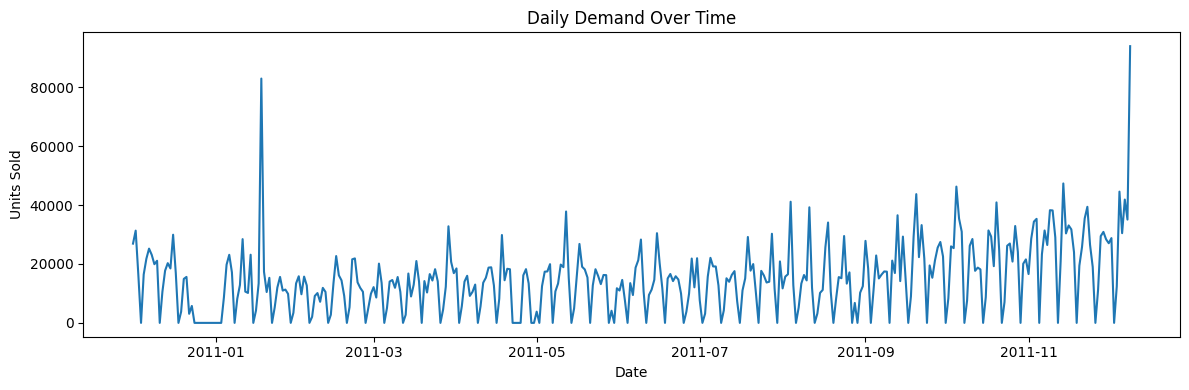

In [27]:
plt.figure(figsize=(12,4))
plt.plot(daily_demand['Date'], daily_demand['Daily_Quantity'])
plt.title("Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()


In [28]:
daily_demand['Date'] = pd.to_datetime(daily_demand['Date'])

full_range = pd.date_range(
    start=daily_demand['Date'].min(),
    end=daily_demand['Date'].max()
)

missing_dates = full_range.difference(daily_demand['Date'])
len(missing_dates)

0